In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train") 
out_dir = os.path.join(main_folder, "outputs","extra", "exp12_film_fusion_effB1_internal_early_modulation_freeze_backbone_BN_fix_film_identity")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_early_modulation_freeze_backbone_BN_fix_film_identity"  # 

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    identity_init=True, # film identity initialization instead of random
    ##film related parameter
    film_start_idx=0,                   # to update the backbone block at early stage on index 0 (1st block of EfficientNet)
    apply_to_all_after=False,            # False: to not apply FiLM on multiple blocks, just single block with the index passed
    use_bn_affine=True,                # False: to not use learnable affine parameter of Batch Normalization instead use FiLM generated affine parameters(gamma and beta)
    freeze_backbone=True,              # True: Freeze backbone
    BN_running_state_frozen=False
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp12_film_fusion_effB1_internal_early_modulation_freeze_backbone_BN_fix_film_identity: Fold 1 ===
[TRAIN BATCH 247] preds min=2.4499 max=10.6251 mean=5.8533var=4.8903
[TRAIN BATCH 247] loss=1908.7491
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=40.9421 | ValRMSE: 39.4851
[TRAIN BATCH 247] preds min=1.8524 max=22.5270 mean=12.6029var=21.1463
[TRAIN BATCH 247] loss=1247.2267
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=35.5473 | ValRMSE: 34.9414
[TRAIN BATCH 247] preds min=7.3015 max=38.1787 mean=20.5180var=65.7427
[TRAIN BATCH 247] loss=579.0512
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=30.5354 | ValRMSE: 31.2966
[TRAIN BATCH 247] preds min=8.7597 max=54.9887 mean=25.8724var=109.0013
[TRAIN BATCH 247] loss=847.6337
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=27.2068 | ValRMSE: 29.4764
[TRAIN BATCH 247] preds min=7.6065 max=44.9337 mean=28.7833var=86.7163
[TRAIN BATCH 247] loss=656.2847
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=25.7619 | ValRMSE: 28.5550
[TRAIN BATCH 247] preds min=0.2849 max=59.5969 mea

In [5]:

import pandas as pd
df_copy = df.copy(deep=True)
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 27.3660 (n=1983)
Fold 2 OOF RMSE: 26.3580 (n=1983)
Fold 3 OOF RMSE: 25.6228 (n=1982)
Fold 4 OOF RMSE: 26.5150 (n=1982)
Fold 5 OOF RMSE: 27.1460 (n=1982)


### Train and Validation RMSE Curve

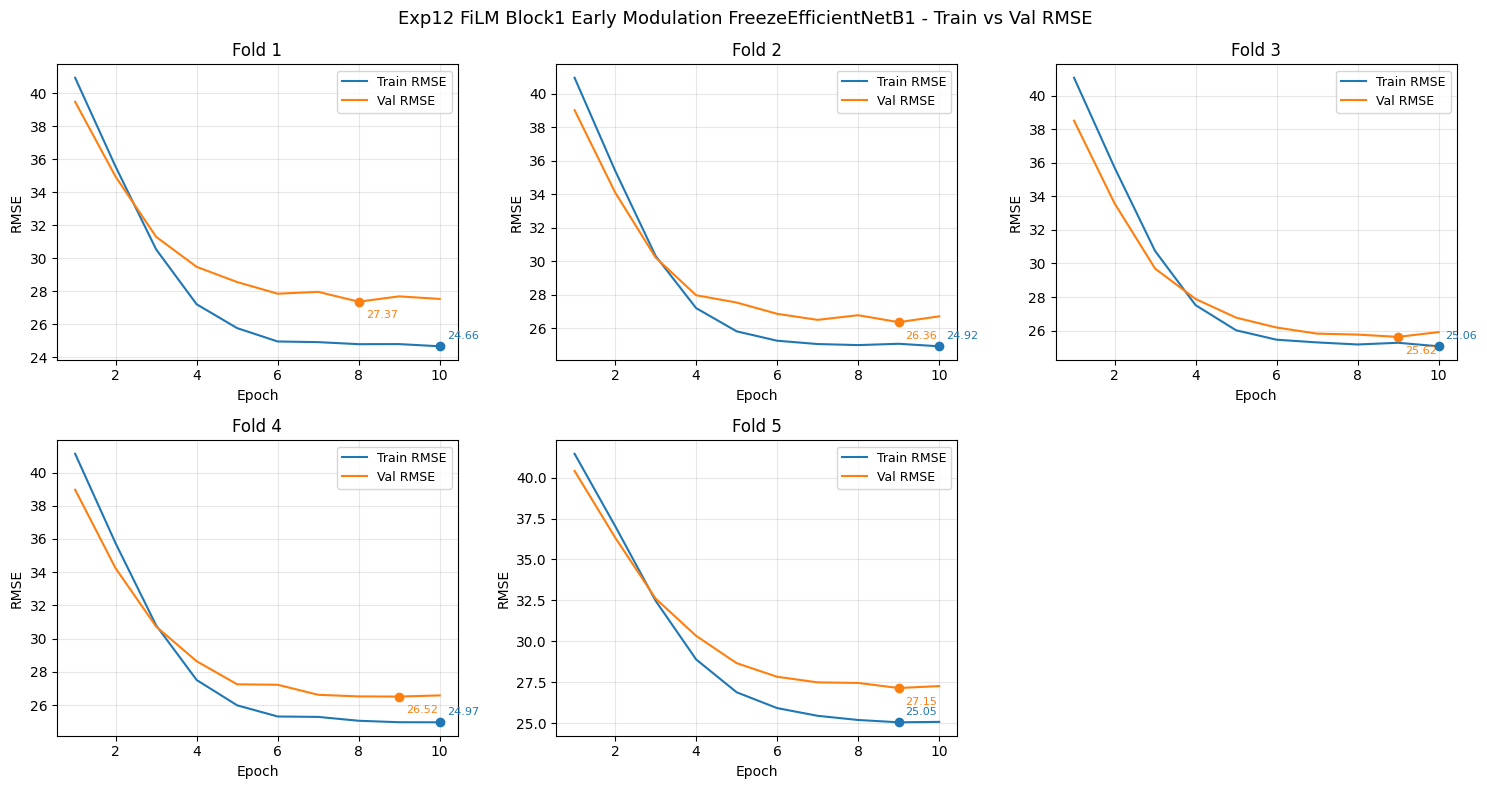

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM Block1 Early Modulation FreezeEfficientNetB1")

In [7]:
df = df_copy

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    identity_init=True, # film identity initialization instead of random
    ##film related parameter
    film_start_idx=0,                   # to update the backbone block at early stage on index 0 (1st block of EfficientNet)
    apply_to_all_after=False,            # False: to not apply FiLM on multiple blocks, just single block with the index passed
    use_bn_affine=True,                # False: to not use learnable affine parameter of Batch Normalization instead use FiLM generated affine parameters(gamma and beta)
    freeze_backbone=True,              # True: Freeze backbone
    BN_running_state_frozen=True
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp12_film_fusion_effB1_internal_early_modulation_freeze_backbone_BN_fix_film_identity: Fold 1 ===
[TRAIN BATCH 247] preds min=-0.0922 max=0.1430 mean=0.0186var=0.0043
[TRAIN BATCH 247] loss=2171.1672
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=260107142046.9001 | ValRMSE: 436419395584.0000
[TRAIN BATCH 247] preds min=-0.1383 max=0.1534 mean=0.0473var=0.0070
[TRAIN BATCH 247] loss=2364.3987
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=4047432764045.2319 | ValRMSE: 435420561408.0000
[TRAIN BATCH 247] preds min=-0.1160 max=0.2281 mean=0.0247var=0.0077
[TRAIN BATCH 247] loss=2546.3706
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=968212132643.4390 | ValRMSE: 434270863360.0000
[TRAIN BATCH 247] preds min=-0.0944 max=0.2027 mean=0.0493var=0.0065
[TRAIN BATCH 247] loss=1492.2026
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=936155673336.6620 | ValRMSE: 435662323712.0000
[TRAIN BATCH 247] preds min=-0.1901 max=0.1916 mean=0.0261var=0.0079
[TRAIN BATCH 247] loss=2136.2383
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=97

In [9]:

import pandas as pd

df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 434086496122.8267 (n=1983)
Fold 2 OOF RMSE: 31148786608270.4844 (n=1983)
Fold 3 OOF RMSE: 4184451409.7142 (n=1982)
Fold 4 OOF RMSE: 498439790557.1298 (n=1982)
Fold 5 OOF RMSE: 156734603249.9305 (n=1982)


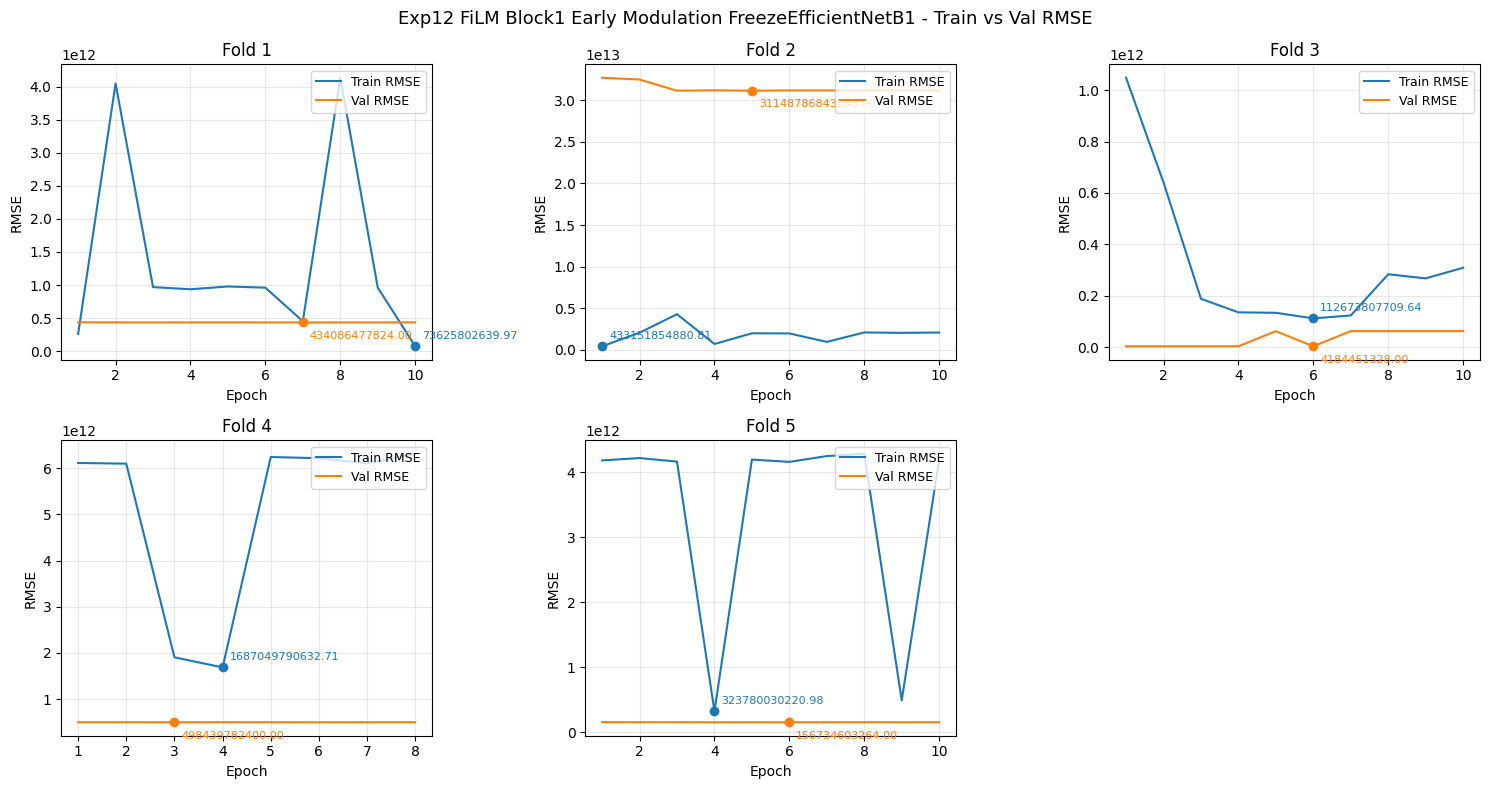

In [10]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM Block1 Early Modulation FreezeEfficientNetB1")